<a href="https://colab.research.google.com/github/gregomatias/DataScienceII_AnalisisVivienda/blob/main/DataScienceIIMatias_Grego_E1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Abstract
Este proyecto analiza los factores que influyen en el precio de las viviendas, con el objetivo de entender qué variables impactan más en su valor.

Mi motivación es ayudar a compradores, vendedores e inversores a tomar decisiones más informadas en el mercado inmobiliario.

La base objetivo incluye agentes inmobiliarios, inversores y público interesado en la compra de propiedades.

##Preguntas
1. ¿Cómo influye el tamaño de la propiedad en el precio?
2. ¿La cantidad de habitaciones impacta significativamente en el valor?
3. ¿Qué zonas presentan precios más altos?
4. ¿Existe relación entre antigüedad y precio?

Estas preguntas serán contestadas mediante análisis exploratorio de datos (EDA) utilizando visualizaciones como scatter plots, boxplots y análisis de correlación.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.info()

# rellenar nulos
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## Metadata
- Filas Aproximadas: 20.000
- Columnas: 10
- Variables: numéricas y categóricas
- Variable objetivo: median_house_value

No se detectan valores faltantes significativos luego del tratamiento de datos.

## EDA
Realizo el análisis exploratorio de los datos.

### Precio vs Tamaño

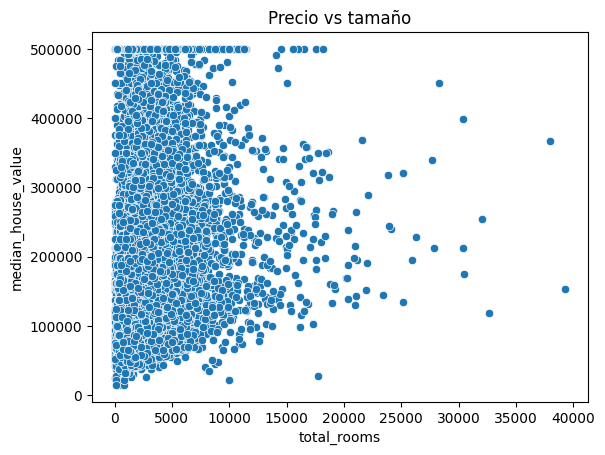

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="total_rooms", y="median_house_value")
plt.title("Precio vs tamaño")
plt.show()


Se observa una relación positiva entre el tamaño de la vivienda y su precio, aunque con alta dispersión, lo que indica que no es el único factor determinante.

Nota:
La variable total_rooms representa la cantidad total de habitaciones por zona y no por vivienda individual, lo que explica los valores elevados observados.

Esto implica que la relación con el precio debe interpretarse a nivel agregado y no como una característica directa de una propiedad individual.

### Precio Por Zona
Analizo si hay una correlacion entre el precio y la zona de la vivienda.

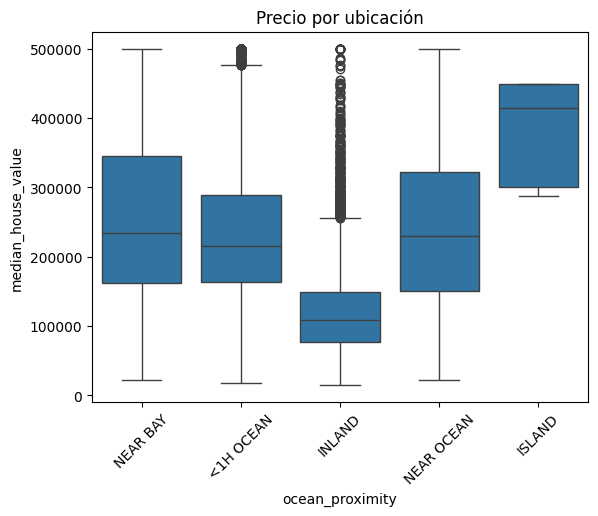

In [ ]:
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value")
plt.xticks(rotation=45)
plt.title("Precio por ubicación")
plt.show()

Las viviendas ubicadas cerca de las playas presentan precios más elevados, indicando  que la ubicación es un factor importante en la valorización.

### Precio vs los Ingresos

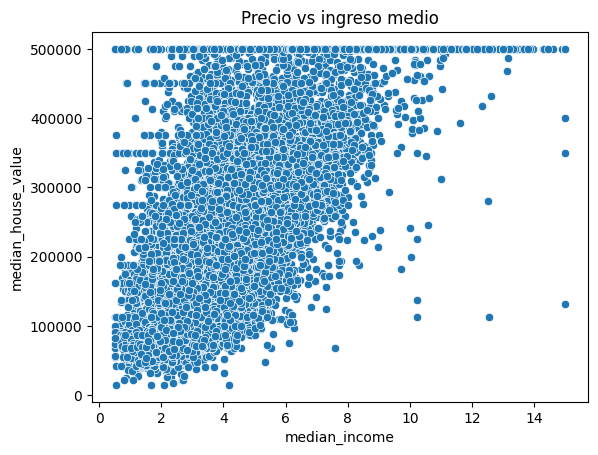

In [ ]:
sns.scatterplot(data=df, x="median_income", y="median_house_value")
plt.title("Precio vs ingreso medio")
plt.show()

Existe una fuerte correlación positiva entre el ingreso medio de la zona y el precio de las viviendas, sugiriendo que zonas más ricas tienen propiedades más caras.

### Correlaciones multivariadas

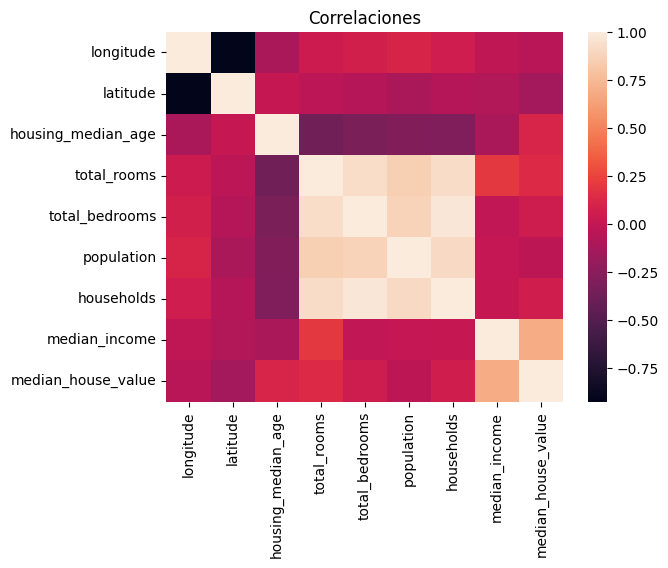

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=False)
plt.title("Correlaciones")
plt.show()

El análisis de correlación muestra que la variable más asociada al precio es el ingreso medio, seguido por variables relacionadas al tamaño de la vivienda.

### Distribución de precios

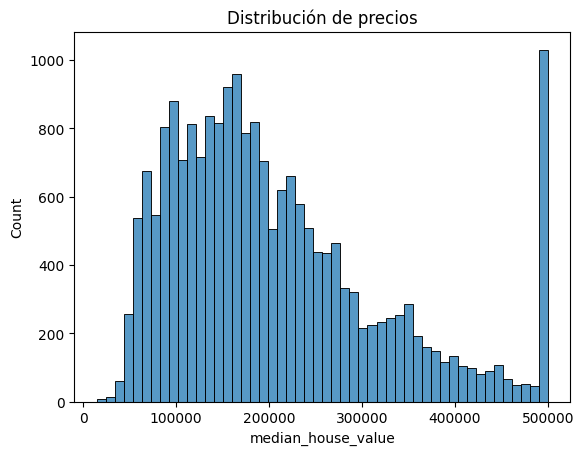

In [ ]:
sns.histplot(df["median_house_value"], bins=50)
plt.title("Distribución de precios")
plt.show()

La distribución de precios muestra una concentración en valores medios, con presencia de outliers en precios altos.

## Respuestas Insights
- Existe una fuerte relación entre el ingreso medio de la zona y el precio de las viviendas.
- Las propiedades cercanas al océano presentan precios significativamente más altos.
- El tamaño de la vivienda influye en el precio, pero no de forma lineal.
- La ubicación es uno de los factores más determinantes del valor inmobiliario.

## Conclusión

El análisis demuestra que el precio de las viviendas está fuertemente influenciado por factores socioeconómicos y geográficos.

En particular, el ingreso medio de la zona y la ubicación son variables clave, mientras que el tamaño de la propiedad tiene un impacto menor al esperado.

Estos resultados pueden ser utilizados para mejorar estrategias de inversión.